# Módulo 1 — Riesgo de Crédito
## Notebook 3: Modelado y Scoring

---

**Objetivo:**  
Construir y comparar tres modelos de clasificación para predecir el riesgo de impago.  
El modelo ganador (Random Forest) se interpretará con SHAP para extraer conclusiones accionables de negocio.

**Input:** `datos/procesados/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`  
**Modelos:** Regresión Logística · Random Forest · XGBoost

---

## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [2]:
X_train = pd.read_csv('../../datos/procesados/X_train.csv')
X_test  = pd.read_csv('../../datos/procesados/X_test.csv')
y_train = pd.read_csv('../../datos/procesados/y_train.csv').squeeze()
y_test  = pd.read_csv('../../datos/procesados/y_test.csv').squeeze()

print(f'✅ Datos cargados')
print(f'   Train: {X_train.shape[0]} muestras × {X_train.shape[1]} columnas')
print(f'   Test : {X_test.shape[0]} muestras × {X_test.shape[1]} columnas')

✅ Datos cargados
   Train: 1120 muestras × 48 columnas
   Test : 200 muestras × 48 columnas


## 2. Función de evaluación

> **¿Por qué no usamos solo el accuracy?**  
> Con un desbalance 70/30, un modelo que prediga siempre "buen pagador" tendría un 70% de accuracy — pero sería inútil para el negocio. Las métricas relevantes en scoring son **Precision**, **Recall** y **AUC-ROC**.

In [3]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)

    print(f'\n{"="*55}')
    print(f'  {nombre}')
    print(f'{"="*55}')
    print(f'  AUC-ROC : {auc:.4f}')
    print()
    print(classification_report(y_test, y_pred,
                                target_names=['Buen pagador', 'Mal pagador']))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['Buen pagador', 'Mal pagador']
    ).plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'Matriz de confusión — {nombre}', fontweight='bold')

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, color='#1565C0', lw=2, label=f'AUC = {auc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Clasificador aleatorio')
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title(f'Curva ROC — {nombre}', fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {'modelo': nombre, 'auc': round(auc, 4)}

print('✅ Función de evaluación definida')

✅ Función de evaluación definida


## 3. Modelo 1 — Regresión Logística

El modelo más simple e interpretable. Sirve como **línea base (baseline)** para comparar los modelos más complejos.


  Regresión Logística
  AUC-ROC : 0.7977

              precision    recall  f1-score   support

Buen pagador       0.85      0.85      0.85       140
 Mal pagador       0.65      0.65      0.65        60

    accuracy                           0.79       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.79      0.79      0.79       200



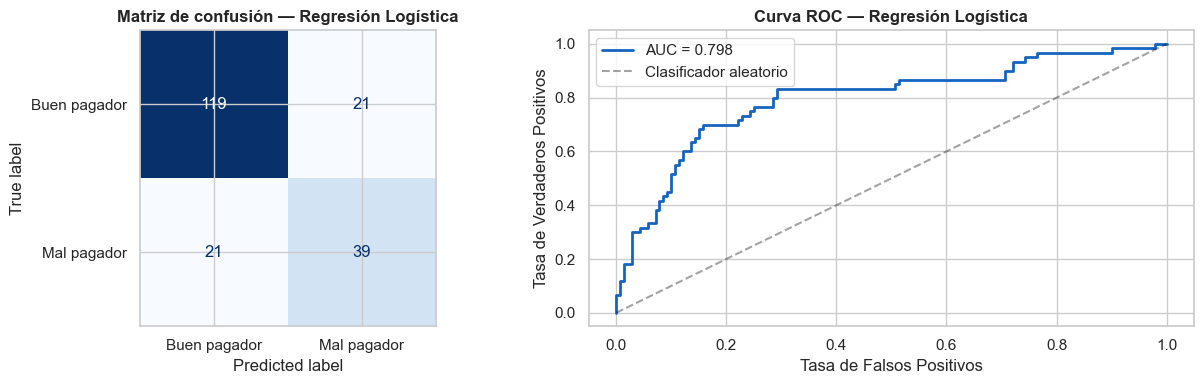

In [4]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
resultado_lr = evaluar_modelo('Regresión Logística', lr, X_test, y_test)

## 4. Modelo 2 — Random Forest

Conjunto de árboles de decisión que vota por mayoría. Más robusto que la regresión logística,  
captura relaciones no lineales y es menos sensible a outliers.


  Random Forest
  AUC-ROC : 0.7774

              precision    recall  f1-score   support

Buen pagador       0.83      0.82      0.82       140
 Mal pagador       0.59      0.60      0.60        60

    accuracy                           0.76       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.76      0.76      0.76       200



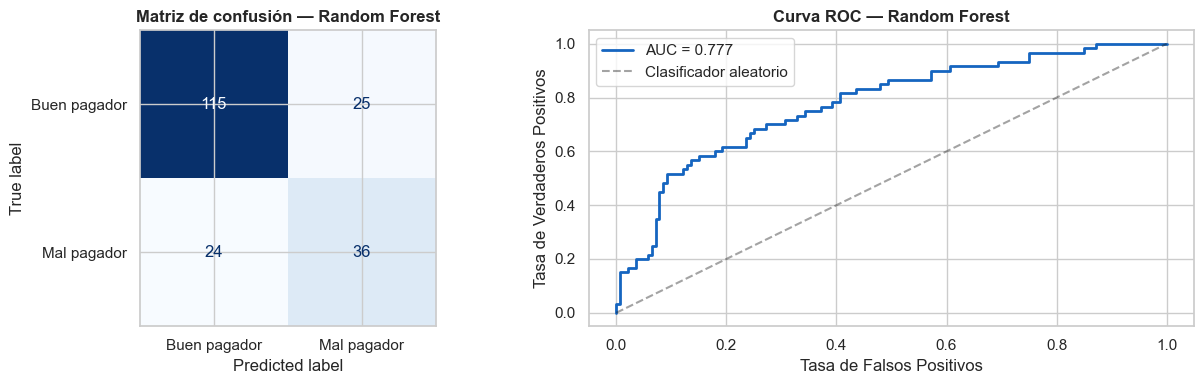

In [5]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
resultado_rf = evaluar_modelo('Random Forest', rf, X_test, y_test)

## 5. Modelo 3 — XGBoost

Gradient boosting de alta performance. Construye árboles secuencialmente, donde cada uno  
corrige los errores del anterior. Suele ser el modelo más potente en datos tabulares.


  XGBoost
  AUC-ROC : 0.7812

              precision    recall  f1-score   support

Buen pagador       0.83      0.86      0.85       140
 Mal pagador       0.65      0.60      0.63        60

    accuracy                           0.79       200
   macro avg       0.74      0.73      0.74       200
weighted avg       0.78      0.79      0.78       200



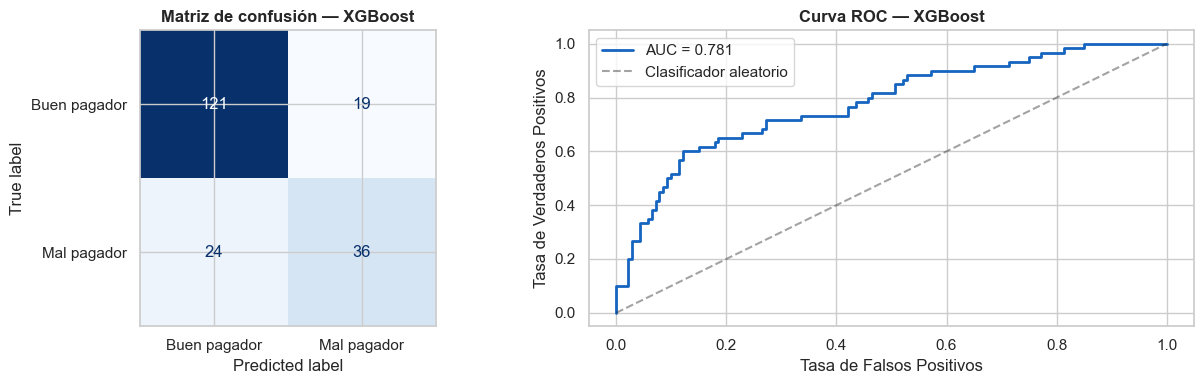

In [6]:
xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42
)
xgb.fit(X_train, y_train)
resultado_xgb = evaluar_modelo('XGBoost', xgb, X_test, y_test)

## 6. Comparativa de modelos

Ranking de modelos por AUC-ROC:
             modelo    auc
Regresión Logística 0.7977
            XGBoost 0.7812
      Random Forest 0.7774


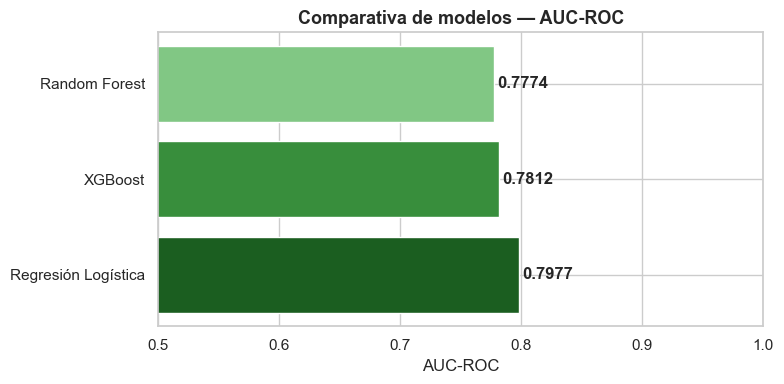

In [7]:
resultados = pd.DataFrame([resultado_lr, resultado_rf, resultado_xgb])
resultados = resultados.sort_values('auc', ascending=False).reset_index(drop=True)

print('Ranking de modelos por AUC-ROC:')
print(resultados.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colores = ['#1B5E20', '#388E3C', '#81C784']
bars = ax.barh(resultados['modelo'], resultados['auc'], color=colores)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('AUC-ROC')
ax.set_title('Comparativa de modelos — AUC-ROC', fontsize=13, fontweight='bold')
for bar, val in zip(bars, resultados['auc']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Interpretabilidad con SHAP — Random Forest

Un modelo predictivo sin explicación no es útil en banca — los comités de riesgo necesitan entender  
**por qué** el modelo asigna un score alto o bajo a un cliente.

**SHAP** (SHapley Additive exPlanations) descompone cada predicción en la contribución individual  
de cada variable. Usamos Random Forest por ser el modelo con mejor AUC-ROC (0.7743).

In [13]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

# Seleccionamos clase 1 (mal pagador) para los gráficos
shap_values_clase1 = shap_values[:, :, 1]

print('✅ SHAP values calculados')

✅ SHAP values calculados


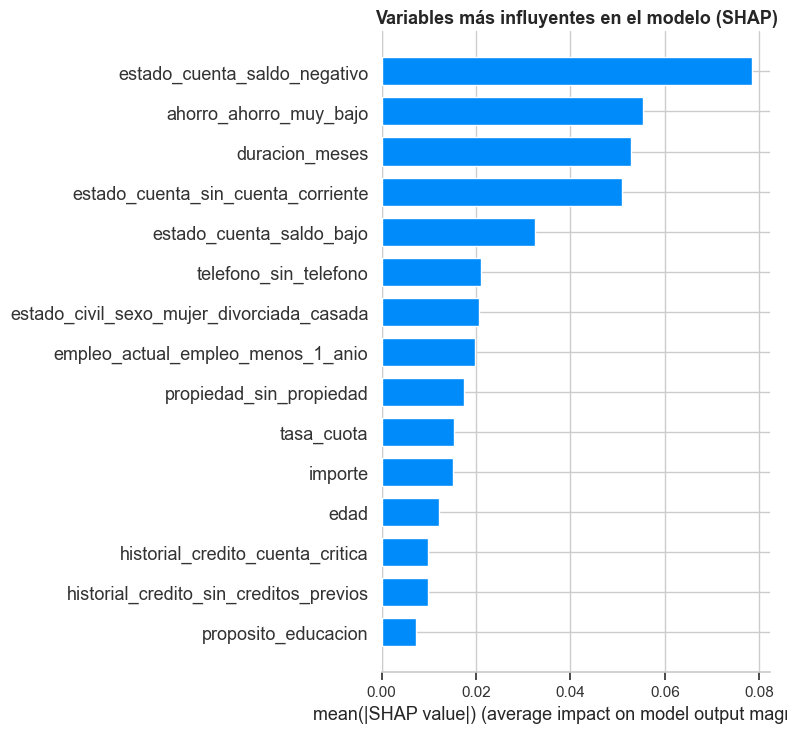

In [14]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_clase1, X_test, plot_type='bar', max_display=15, show=False)
plt.title('Variables más influyentes en el modelo (SHAP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

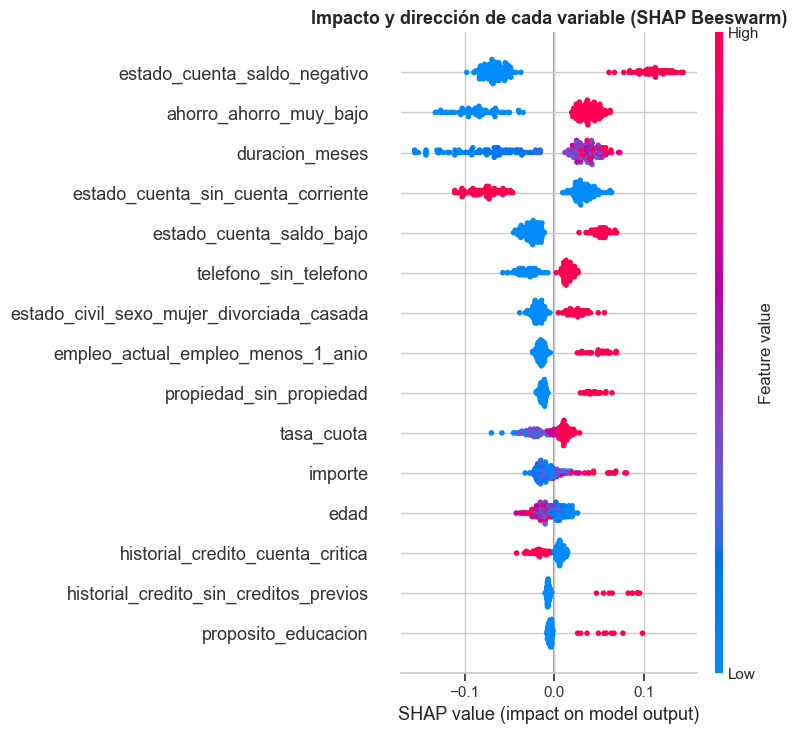

In [15]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_clase1, X_test, max_display=15, show=False)
plt.title('Impacto y dirección de cada variable (SHAP Beeswarm)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Conclusiones del módulo

---

### Rendimiento de los modelos

| Modelo | AUC-ROC |
|--------|---------|
| Regresión Logística | **0.7977** |
| XGBoost | 0.7812 |
| Random Forest | 0.7774 |

Los tres modelos superan ampliamente el baseline del 50% (clasificador aleatorio), confirmando que las variables del dataset tienen poder predictivo real sobre el riesgo de impago. La Regresión Logística obtiene el mejor AUC-ROC con **0.7977**, superando a los modelos de ensemble. Esto sugiere que las relaciones entre variables y riesgo son en gran medida lineales en este dataset, y que la mayor complejidad de Random Forest y XGBoost no aporta ventaja adicional.

En un entorno productivo esto es una buena noticia: la Regresión Logística es más fácil de auditar, más rápida de inferir y más aceptada por los reguladores bancarios (Basilea III exige que los modelos de scoring sean interpretables).

### Variables más relevantes para el scoring (SHAP)

El análisis SHAP sobre Random Forest identifica las siguientes variables como las más influyentes:

- **Estado de cuenta con saldo negativo** — la variable de mayor impacto global. El beeswarm muestra que valores altos (rojo) se asocian fuertemente con mayor riesgo de impago.
- **Ahorro muy bajo** — segunda variable más influyente. Clientes sin apenas ahorro presentan un perfil de riesgo claramente más elevado.
- **Duración del crédito** — plazos más largos (valores altos, rojo) aumentan consistentemente la probabilidad de impago.
- **Sin cuenta corriente** — la ausencia de cuenta corriente es también un predictor potente de riesgo, coherente con el primer hallazgo.
- **Empleo inferior a 1 año** — poca antigüedad laboral eleva el riesgo, probablemente por la inestabilidad de ingresos.
- **Sin propiedad** — carecer de activos como garantía se asocia a mayor riesgo.
- **Propósito educación** — los créditos para educación presentan una tasa de mora superior a la media.

### Recomendaciones de negocio

1. **Modelo recomendado:** La Regresión Logística es la opción preferible para producción — mejor AUC-ROC, totalmente interpretable y alineada con los requisitos regulatorios del sector bancario.
2. **Variables de alerta prioritaria:** Un cliente con saldo negativo, ahorro muy bajo y crédito de larga duración debe activar una revisión manual independientemente del score automático.
3. **Política de umbral:** El umbral de decisión debe calibrarse según el coste asimétrico del negocio — rechazar a un buen cliente tiene un coste menor que aprobar a un mal pagador.
4. **Monitorización continua:** El modelo debe recalibrarse periódicamente, ya que el comportamiento crediticio evoluciona con el ciclo económico.

